In [ ]:
import os
print("รายการไฟล์ในเครื่อง Colab ปัจจุบัน:")
print(os.listdir('/content'))

รายการไฟล์ในเครื่อง Colab ปัจจุบัน:
['.config', 'test3.jpg', 'MNV2_Project.keras', '.ipynb_checkpoints', 'sample_data']


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# --- แก้ชื่อไฟล์ตรงนี้ให้ตรงกับที่คุณเห็นในข้อ 1 ---
model_filename = 'MNV2_Project.keras'  # หรือ .keras แล้วแต่ที่คุณเซฟไว้
# -----------------------------------------------

path = f'/content/{model_filename}'

try:
    print(f"⏳ กำลังโหลดโมเดลจาก: {path}")
    model = tf.keras.models.load_model(path)
    print("✅ โหลดโมเดลสำเร็จ! พร้อมใช้งานครับ")
except Exception as e:
    print(f"❌ ยังหาไม่เจอครับ: {e}")
    print("ลองเช็คดูว่าชื่อไฟล์พิมพ์ถูกไหม หรือลืมเซฟไฟล์หรือเปล่า?")

⏳ กำลังโหลดโมเดลจาก: /content/MNV2_Project.keras
✅ โหลดโมเดลสำเร็จ! พร้อมใช้งานครับ


In [ ]:
# รายชื่ออาหาร (เรียงตามตัวอักษรภาษาอังกฤษ A-Z เหมือนชื่อโฟลเดอร์ตอนเทรน)
class_names = [
    'Chicken Khao Soi', 'Chicken Rice', 'Fried rice',
    'Massaman curry', 'Pad Krapow', 'Pad Thai',
    'Red Pork Rice', 'Rice with omelet', 'Somtam', 'Tom Yum Goong'
]

# ดิกชันนารีแปลไทย
thai_food_names = {
    'Chicken Khao Soi': 'ข้าวซอยไก่', 'Chicken Rice': 'ข้าวมันไก่',
    'Fried rice': 'ข้าวผัด', 'Massaman curry': 'แกงมัสมั่น',
    'Pad Krapow': 'ผัดกะเพรา', 'Pad Thai': 'ผัดไทย',
    'Red Pork Rice': 'ข้าวหมูแดง', 'Rice with omelet': 'ข้าวไข่เจียว',
    'Somtam': 'ส้มตำ', 'Tom Yum Goong': 'ต้มยำกุ้ง'
}

In [ ]:
def predict_image(img_path):
    # ขนาดภาพต้องตรงกับตอนเทรน (224x224)
    img_height = 224
    img_width = 224

    try:
        # 1. โหลดและเตรียมภาพ
        img = tf.keras.utils.load_img(img_path, target_size=(img_height, img_width))
        img_array = tf.keras.utils.img_to_array(img)
        img_array = tf.expand_dims(img_array, 0) # แปลงเป็น (1, 224, 224, 3)

        # 2. ให้โมเดลทำนาย
        predictions = model.predict(img_array)
        raw_scores = predictions[0] # ค่าดิบ

        # 3. หาอันดับสูงสุด
        top_index = raw_scores.argsort()[::-1][0] # Index ของตัวที่มากสุด
        top_score = raw_scores[top_index]         # คะแนนดิบตัวที่มากสุด
        predicted_eng = class_names[top_index]    # ชื่อ Eng
        predicted_thai = thai_food_names.get(predicted_eng, predicted_eng)

        # 4. แสดงผล
        print("\n" + "="*40)
        print(f"🍲 ผลการทำนาย: {predicted_thai}")
        print(f"🇺🇸 ชื่อไฟล์: {predicted_eng}")
        print(f"🔢 Raw Score: {top_score:.4f}") # ทศนิยม 4 ตำแหน่ง
        print("="*40)

        # แสดง Raw Score ทั้งหมด
        print("\n📊 คะแนนดิบทุกเมนู:")
        for i, score in enumerate(raw_scores):
            print(f" - {class_names[i]}: {score:.4f}")

        # โชว์รูป
        plt.imshow(img)
        plt.axis('off')
        plt.show()

    except Exception as e:
        print(f"❌ Error: {e}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

🍲 ผลการทำนาย: ส้มตำ
🇺🇸 ชื่อไฟล์: Somtam
🔢 Raw Score: 0.4247

📊 คะแนนดิบทุกเมนู:
 - Chicken Khao Soi: 0.0000
 - Chicken Rice: 0.0001
 - Fried rice: 0.0137
 - Massaman curry: 0.0004
 - Pad Krapow: 0.0164
 - Pad Thai: 0.3732
 - Red Pork Rice: 0.1706
 - Rice with omelet: 0.0002
 - Somtam: 0.4247
 - Tom Yum Goong: 0.0006


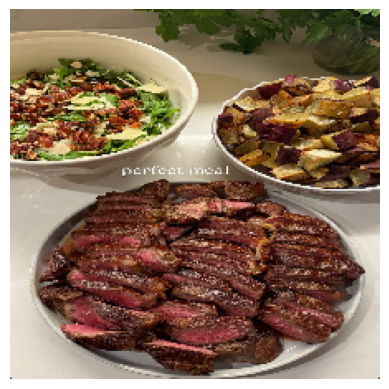

In [ ]:
# ใส่ชื่อไฟล์รูปภาพที่คุณอัปโหลดเข้ามา
predict_image('test3.jpg')

In [24]:
print(tf.__version__)
print(tf.keras.__version__)

2.19.0
3.10.0
